In [ ]:
# -----------------------------
# 1. Packages
# -----------------------------
packages <- c("tidyverse", "lubridate", "scales", "janitor", "corrplot")
installed <- rownames(installed.packages())
for (p in packages) {
  if (!(p %in% installed)) install.packages(p)
}

library(tidyverse)
library(lubridate)
library(scales)
library(janitor)
library(corrplot)


In [ ]:
base_url = 'https://raw.githubusercontent.com/theomniscient-omnipotentrat/DBA-Final-Assignment/6d8b5a6f7e762e4d73bea18d7e24622f75441726/cleaned_dataset/'

In [ ]:
# -----------------------------
# 2. Load cleaned datasets
# -----------------------------
customers  <- read.csv(paste0(base_url, "customers_clean.csv"),  stringsAsFactors = FALSE)
orders     <- read.csv(paste0(base_url, "orders_clean.csv"),     stringsAsFactors = FALSE)
deliveries <- read.csv(paste0(base_url, "deliveries_clean.csv"), stringsAsFactors = FALSE)
drivers    <- read.csv(paste0(base_url, "drivers_clean.csv"),    stringsAsFactors = FALSE)
vehicles   <- read.csv(paste0(base_url, "vehicles_clean.csv"),   stringsAsFactors = FALSE)
hubs       <- read.csv(paste0(base_url, "hubs_clean.csv"),       stringsAsFactors = FALSE)
incidents  <- read.csv(paste0(base_url, "incidents_clean.csv"),  stringsAsFactors = FALSE)
complaints <- read.csv(paste0(base_url, "complaints_clean.csv"), stringsAsFactors = FALSE)
app_events <- read.csv(paste0(base_url, "app_events_clean.csv"), stringsAsFactors = FALSE)



In [ ]:
# -----------------------------
# 3. Create integrated analytical dataset
# -----------------------------
delivery_analysis <- deliveries %>%
  left_join(hubs %>% select(hub_id, hub_name, hub_zone = zone, hub_type, capacity_score), by = "hub_id") %>%
  left_join(drivers %>% select(driver_id, base_zone, employment_type, years_experience,
                               training_score, driver_rating, performance_score, performance_tier), by = "driver_id") %>%
  left_join(vehicles %>% select(vehicle_id, vehicle_type, assigned_zone, battery_health_pct,
                                odometer_km, maintenance_status, age_months, maintenance_risk_flag), by = "vehicle_id") %>%
  mutate(
    dispatch_time = ymd_hms(dispatch_time),
    delivery_completed_at = ymd_hms(delivery_completed_at),
    failure_flag = if_else(delivery_status == "Failed", 1, 0),
    delayed_status_flag = if_else(delivery_status == "Delayed", 1, 0),
    complaint_flag = if_else(order_id %in% complaints$order_id, 1, 0),
    incident_flag = if_else(delivery_id %in% incidents$delivery_id, 1, 0),
    cost_per_km = fuel_or_charge_cost / route_distance_km,
    month = floor_date(dispatch_time, "month")
  )

valid_duration <- delivery_analysis %>%
  filter(temporal_anomaly_flag == 0)

In [ ]:
# -----------------------------
# 4. Overall KPI summary
# -----------------------------
overall_kpis <- delivery_analysis %>%
  summarise(
    total_deliveries = n(),
    valid_duration_records = sum(temporal_anomaly_flag == 0),
    temporal_anomaly_records = sum(temporal_anomaly_flag == 1),
    late_rate = mean(is_late, na.rm = TRUE),
    failure_rate = mean(failure_flag, na.rm = TRUE),
    complaint_rate = mean(complaint_flag, na.rm = TRUE),
    incident_rate = mean(incident_flag, na.rm = TRUE),
    average_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    average_cost = mean(fuel_or_charge_cost, na.rm = TRUE)
  )

print(overall_kpis)

  total_deliveries valid_duration_records temporal_anomaly_records late_rate
1              950                    886                       64 0.4578947
  failure_rate complaint_rate incident_rate average_rating average_cost
1    0.1389474           0.22     0.2610526       3.864179     12.84129


# A tibble: 8 × 11
  hub_id hub_name      hub_zone deliveries late_rate failure_rate complaint_rate
  <chr>  <chr>         <chr>         <int>     <dbl>        <dbl>          <dbl>
1 H08    Midtown Relay Central         128     0.469       0.203           0.242
2 H05    Central Core  Central         115     0.513       0.2             0.243
3 H06    Airport Hub   Airport         104     0.567       0.144           0.202
4 H04    West Gate     West            127     0.472       0.126           0.205
5 H01    North Exchan… North           136     0.426       0.125           0.191
6 H07    Riverside Hub Riversi…        115     0.4         0.122           0.261
7 H02    South Link    South           106     0.415       0.0943          0.151
8 H03    East Dock     East            119     0.412       0.0924          0.261
# ℹ 4 more variables: incident_rate <dbl>, avg_rating <dbl>, avg_cost <dbl>,
#   avg_route_overrides <dbl>


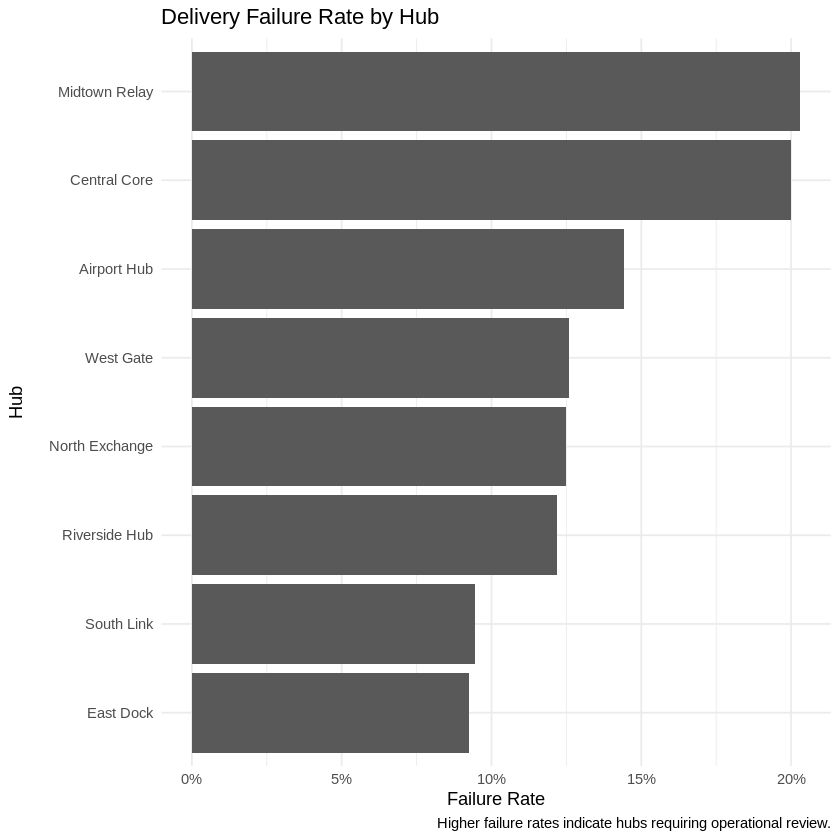

In [ ]:
# -----------------------------
# 5. Hub performance analysis
# -----------------------------
hub_performance <- delivery_analysis %>%
  group_by(hub_id, hub_name, hub_zone) %>%
  summarise(
    deliveries = n(),
    late_rate = mean(is_late, na.rm = TRUE),
    failure_rate = mean(failure_flag, na.rm = TRUE),
    complaint_rate = mean(complaint_flag, na.rm = TRUE),
    incident_rate = mean(incident_flag, na.rm = TRUE),
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    avg_cost = mean(fuel_or_charge_cost, na.rm = TRUE),
    avg_route_overrides = mean(manual_route_override_count, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate))

print(hub_performance)

# Visualisation: failure rate by hub
ggplot(hub_performance, aes(x = reorder(hub_name, failure_rate), y = failure_rate)) +
  geom_col() +
  coord_flip() +
  scale_y_continuous(labels = percent_format()) +
  labs(
    title = "Delivery Failure Rate by Hub",
    x = "Hub",
    y = "Failure Rate",
    caption = "Higher failure rates indicate hubs requiring operational review."
  ) +
  theme_minimal()


# A tibble: 5 × 9
  service_type deliveries late_rate failure_rate complaint_rate avg_delay_hours
  <chr>             <int>     <dbl>        <dbl>          <dbl>           <dbl>
1 Business            126     0.492        0.198          0.222            3.35
2 Medical             108     0.417        0.148          0.194            3.00
3 Passenger           262     0.477        0.145          0.225            2.98
4 Retail              224     0.420        0.125          0.232            2.81
5 Parcel              230     0.474        0.109          0.213            2.73
# ℹ 3 more variables: avg_rating <dbl>, avg_cost <dbl>, avg_order_value <dbl>


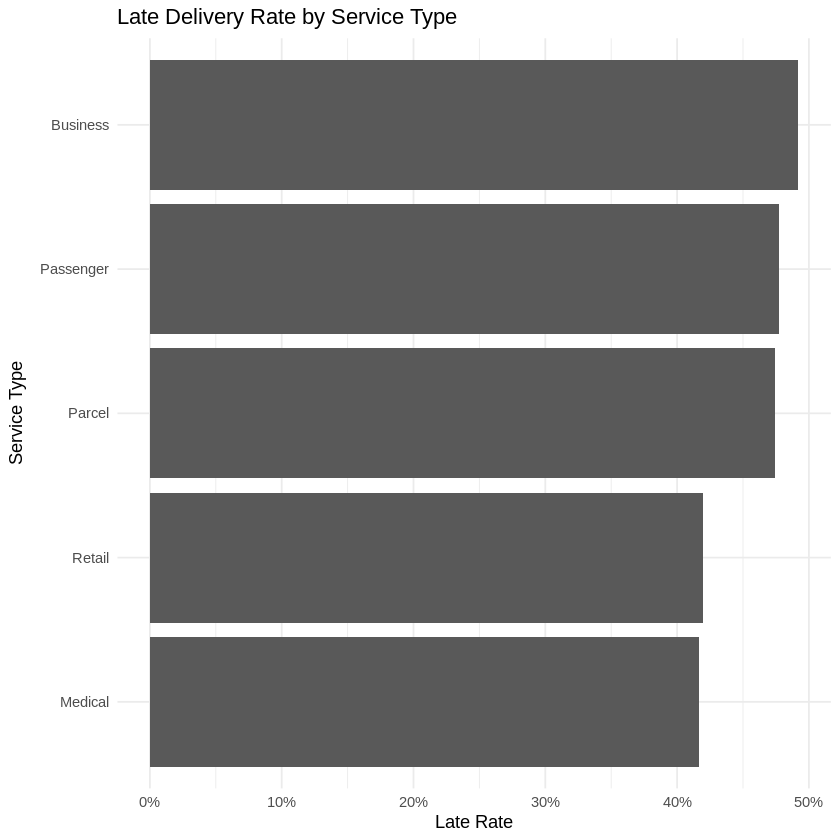

In [ ]:
# -----------------------------
# 6. Service type analysis
# -----------------------------
service_performance <- delivery_analysis %>%
  group_by(service_type) %>%
  summarise(
    deliveries = n(),
    late_rate = mean(is_late, na.rm = TRUE),
    failure_rate = mean(failure_flag, na.rm = TRUE),
    complaint_rate = mean(complaint_flag, na.rm = TRUE),
    avg_delay_hours = mean(delay_hours, na.rm = TRUE),
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    avg_cost = mean(fuel_or_charge_cost, na.rm = TRUE),
    avg_order_value = mean(order_value, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate))

print(service_performance)

# Visualisation: late rate by service type
ggplot(service_performance, aes(x = reorder(service_type, late_rate), y = late_rate)) +
  geom_col() +
  coord_flip() +
  scale_y_continuous(labels = percent_format()) +
  labs(
    title = "Late Delivery Rate by Service Type",
    x = "Service Type",
    y = "Late Rate"
  ) +
  theme_minimal()


# A tibble: 7 × 7
  dropoff_zone deliveries late_rate failure_rate avg_rating avg_cost
  <chr>             <int>     <dbl>        <dbl>      <dbl>    <dbl>
1 North               145     0.524        0.172       3.83     13.3
2 Central             147     0.517        0.170       3.76     12.7
3 South               130     0.438        0.138       3.85     12.4
4 Riverside           141     0.404        0.135       3.95     13.2
5 East                118     0.441        0.119       3.86     12.9
6 West                146     0.411        0.116       3.92     13.2
7 Airport             123     0.463        0.114       3.87     12.1
# ℹ 1 more variable: avg_route_overrides <dbl>


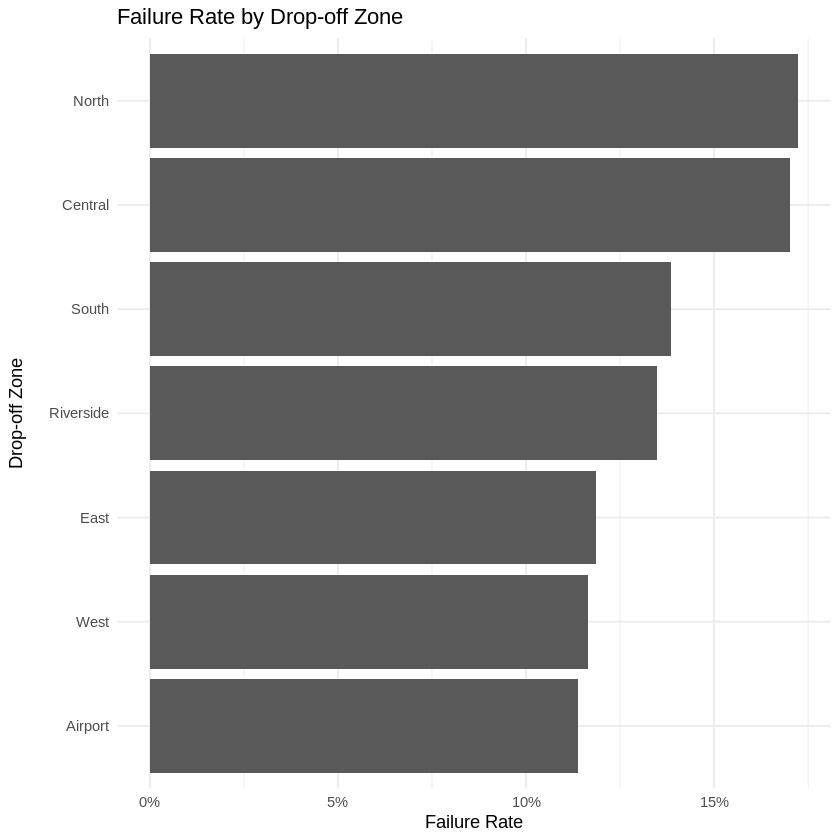

In [ ]:
# -----------------------------
# 7. Zone analysis
# -----------------------------
zone_performance <- delivery_analysis %>%
  group_by(dropoff_zone) %>%
  summarise(
    deliveries = n(),
    late_rate = mean(is_late, na.rm = TRUE),
    failure_rate = mean(failure_flag, na.rm = TRUE),
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    avg_cost = mean(fuel_or_charge_cost, na.rm = TRUE),
    avg_route_overrides = mean(manual_route_override_count, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate))

print(zone_performance)

ggplot(zone_performance, aes(x = reorder(dropoff_zone, failure_rate), y = failure_rate)) +
  geom_col() +
  coord_flip() +
  scale_y_continuous(labels = percent_format()) +
  labs(
    title = "Failure Rate by Drop-off Zone",
    x = "Drop-off Zone",
    y = "Failure Rate"
  ) +
  theme_minimal()


# A tibble: 3 × 7
  performance_tier deliveries late_rate failure_rate avg_rating
  <chr>                 <int>     <dbl>        <dbl>      <dbl>
1 Moderate                 91     0.451        0.176       3.72
2 High                    677     0.468        0.139       3.84
3 Elite                   182     0.423        0.121       4.01
# ℹ 2 more variables: avg_route_overrides <dbl>, avg_training_score <dbl>


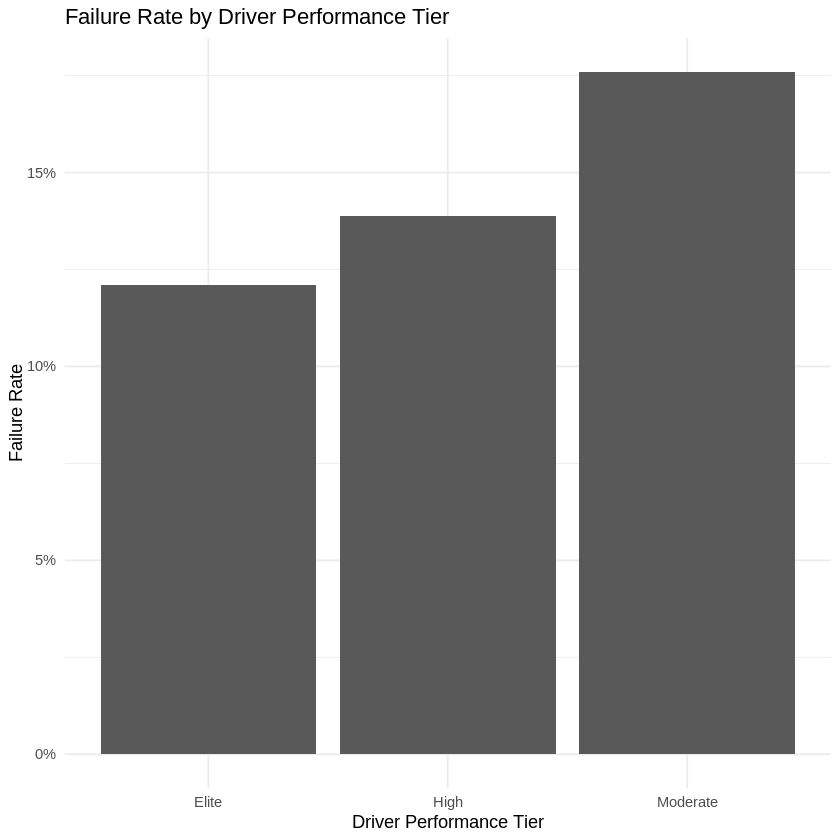

In [ ]:
# -----------------------------
# 8. Driver performance analysis
# -----------------------------
driver_tier_analysis <- delivery_analysis %>%
  group_by(performance_tier) %>%
  summarise(
    deliveries = n(),
    late_rate = mean(is_late, na.rm = TRUE),
    failure_rate = mean(failure_flag, na.rm = TRUE),
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    avg_route_overrides = mean(manual_route_override_count, na.rm = TRUE),
    avg_training_score = mean(training_score, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate))

print(driver_tier_analysis)

ggplot(driver_tier_analysis, aes(x = performance_tier, y = failure_rate)) +
  geom_col() +
  scale_y_continuous(labels = percent_format()) +
  labs(
    title = "Failure Rate by Driver Performance Tier",
    x = "Driver Performance Tier",
    y = "Failure Rate"
  ) +
  theme_minimal()


# A tibble: 3 × 7
  maintenance_status deliveries late_rate failure_rate incident_rate
  <chr>                   <int>     <dbl>        <dbl>         <dbl>
1 InRepair                  254     0.551       0.303          0.276
2 Active                    542     0.434       0.0830         0.255
3 Scheduled                 154     0.390       0.0649         0.260
# ℹ 2 more variables: avg_battery_health <dbl>, avg_cost <dbl>


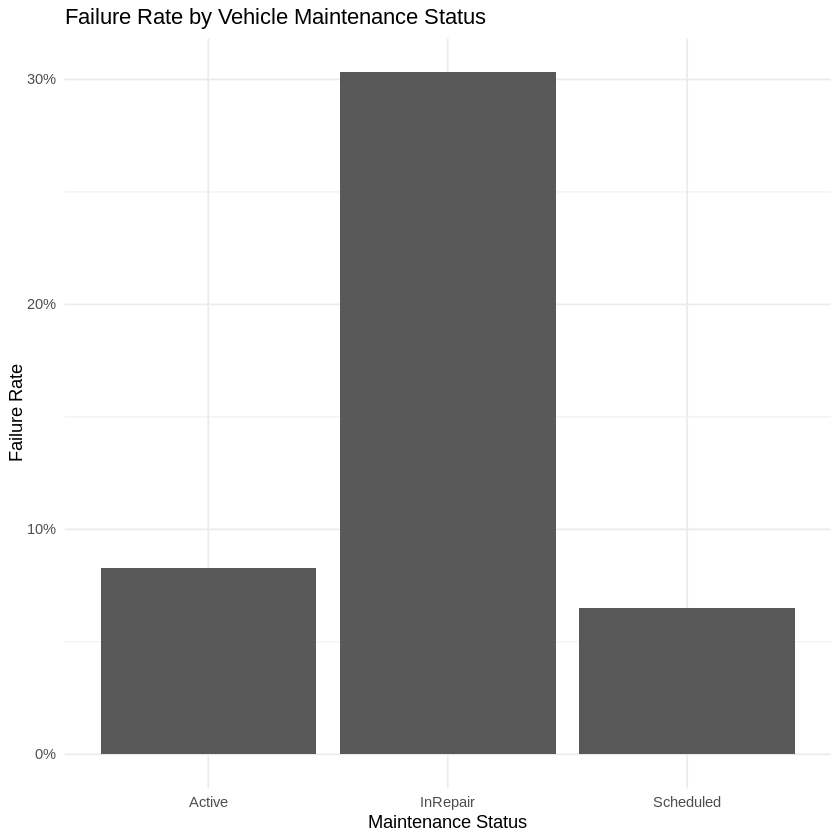

In [ ]:
# -----------------------------
# 9. Vehicle maintenance analysis
# -----------------------------
vehicle_maintenance_analysis <- delivery_analysis %>%
  group_by(maintenance_status) %>%
  summarise(
    deliveries = n(),
    late_rate = mean(is_late, na.rm = TRUE),
    failure_rate = mean(failure_flag, na.rm = TRUE),
    incident_rate = mean(incident_flag, na.rm = TRUE),
    avg_battery_health = mean(battery_health_pct, na.rm = TRUE),
    avg_cost = mean(fuel_or_charge_cost, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate))

print(vehicle_maintenance_analysis)

ggplot(vehicle_maintenance_analysis, aes(x = maintenance_status, y = failure_rate)) +
  geom_col() +
  scale_y_continuous(labels = percent_format()) +
  labs(
    title = "Failure Rate by Vehicle Maintenance Status",
    x = "Maintenance Status",
    y = "Failure Rate"
  ) +
  theme_minimal()

# A tibble: 7 × 6
  complaint_type    complaints avg_resolution_days avg_compensation late_rate
  <chr>                  <int>               <dbl>            <dbl>     <dbl>
1 Delay                    101                7.26             18.8     0.479
2 MissedPickup              64                7.64             22.5     0.523
3 AppIssue                  53                8.60             19.7     0.378
4 DriverBehaviour           51                8.16             22.3     0.342
5 SupportExperience         20                7.45             17.1     0.412
6 Billing                   16                7.75             23.9     0.5  
7 Damage                    15               11.3              24.0     0.273
# ℹ 1 more variable: failed_rate <dbl>


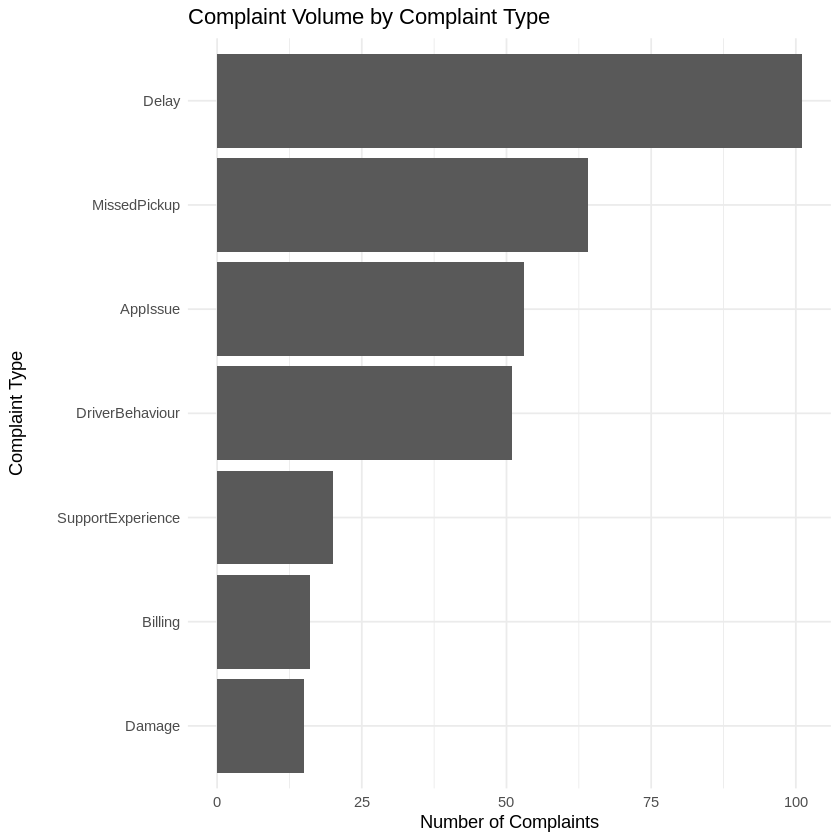

In [ ]:
# -----------------------------
# 10. Complaint analysis
# -----------------------------
complaint_analysis <- complaints %>%
  left_join(orders %>% select(order_id, service_type, priority_level, pickup_zone, dropoff_zone, order_value), by = "order_id") %>%
  left_join(delivery_analysis %>% select(order_id, delivery_status, is_late, delay_hours,
                                        customer_rating_post_delivery, hub_name,
                                        manual_route_override_count), by = "order_id")

complaint_type_analysis <- complaint_analysis %>%
  group_by(complaint_type) %>%
  summarise(
    complaints = n(),
    avg_resolution_days = mean(resolution_days, na.rm = TRUE),
    avg_compensation = mean(compensation_amount, na.rm = TRUE),
    late_rate = mean(is_late, na.rm = TRUE),
    failed_rate = mean(delivery_status == "Failed", na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(complaints))

print(complaint_type_analysis)

ggplot(complaint_type_analysis, aes(x = reorder(complaint_type, complaints), y = complaints)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Complaint Volume by Complaint Type",
    x = "Complaint Type",
    y = "Number of Complaints"
  ) +
  theme_minimal()


# A tibble: 8 × 5
  event_type       events failed_event_rate avg_latency_ms unlinked_session_rate
  <chr>             <int>             <dbl>          <dbl>                 <dbl>
1 chat_escalated       38             0.5             478.                 0.237
2 payment_retry        69             0.275           473.                 0.232
3 cancel_attempt       28             0               417.                 0.286
4 chat_opened          88             0               478.                 0.239
5 delivery_instru…     75             0               496.                 0.213
6 eta_refresh         105             0               452.                 0.210
7 search_route         99             0               457.                 0.202
8 track_order         138             0               461.                 0.232


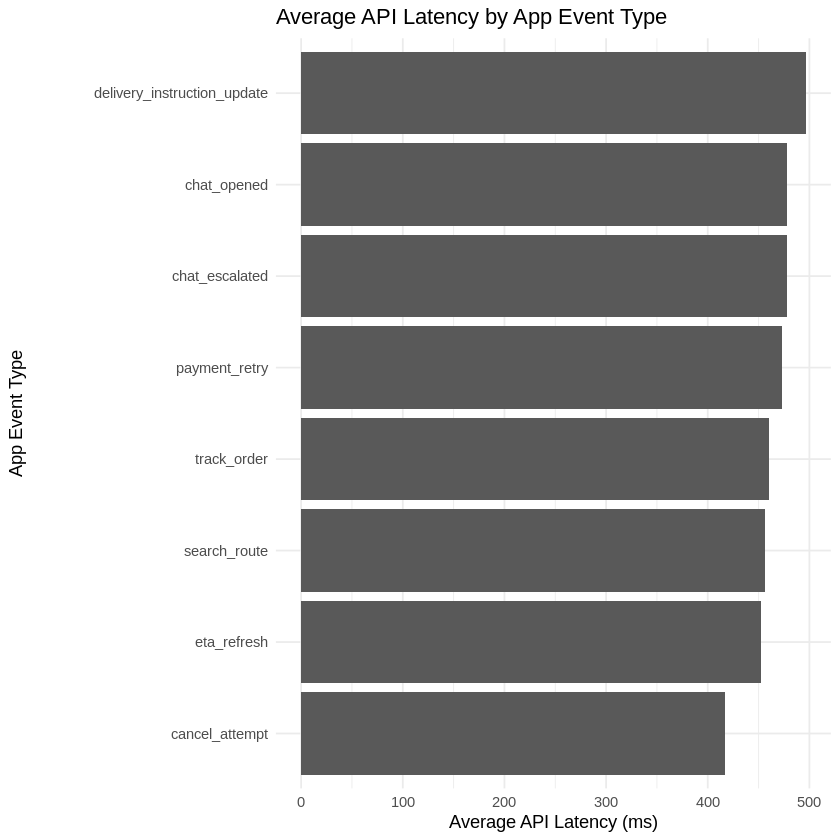

In [ ]:

# -----------------------------
# 11. App event reliability analysis
# -----------------------------
app_event_analysis <- app_events %>%
  mutate(failed_event = if_else(success_flag == 0, 1, 0)) %>%
  group_by(event_type) %>%
  summarise(
    events = n(),
    failed_event_rate = mean(failed_event, na.rm = TRUE),
    avg_latency_ms = mean(api_latency_ms, na.rm = TRUE),
    unlinked_session_rate = mean(is_unlinked_session, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(failed_event_rate))

print(app_event_analysis)

ggplot(app_event_analysis, aes(x = reorder(event_type, avg_latency_ms), y = avg_latency_ms)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Average API Latency by App Event Type",
    x = "App Event Type",
    y = "Average API Latency (ms)"
  ) +
  theme_minimal()

# A tibble: 24 × 6
   month               deliveries late_rate failure_rate avg_cost avg_rating
   <dttm>                   <int>     <dbl>        <dbl>    <dbl>      <dbl>
 1 2024-01-01 00:00:00         45     0.422       0.0222     12.9       3.96
 2 2024-02-01 00:00:00         46     0.413       0.152      12.2       3.96
 3 2024-03-01 00:00:00         52     0.365       0.0962     13.2       3.92
 4 2024-04-01 00:00:00         34     0.471       0.176      12.3       3.79
 5 2024-05-01 00:00:00         35     0.4         0.0571     12.9       3.92
 6 2024-06-01 00:00:00         43     0.442       0.186      12.2       3.77
 7 2024-07-01 00:00:00         33     0.455       0.182      13.4       4.01
 8 2024-08-01 00:00:00         44     0.273       0.0682     14.0       4.09
 9 2024-09-01 00:00:00         41     0.561       0.171      11.8       3.87
10 2024-10-01 00:00:00         32     0.438       0.156      12.0       3.67
# ℹ 14 more rows


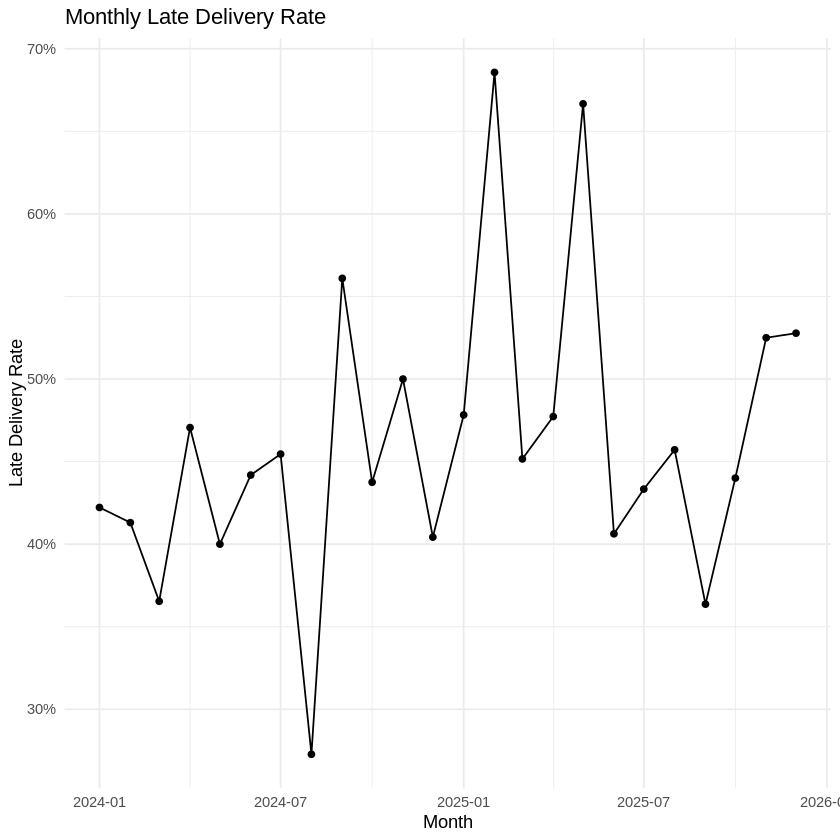

In [ ]:
# -----------------------------
# 12. Monthly operational trend
# -----------------------------
monthly_trend <- delivery_analysis %>%
  group_by(month) %>%
  summarise(
    deliveries = n(),
    late_rate = mean(is_late, na.rm = TRUE),
    failure_rate = mean(failure_flag, na.rm = TRUE),
    avg_cost = mean(fuel_or_charge_cost, na.rm = TRUE),
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    .groups = "drop"
  )

print(monthly_trend)

ggplot(monthly_trend, aes(x = month, y = late_rate)) +
  geom_line() +
  geom_point() +
  scale_y_continuous(labels = percent_format()) +
  labs(
    title = "Monthly Late Delivery Rate",
    x = "Month",
    y = "Late Delivery Rate"
  ) +
  theme_minimal()


                              is_late failure_flag delay_hours
is_late                         1.000        0.407       0.668
failure_flag                    0.407        1.000       0.647
delay_hours                     0.668        0.647       1.000
route_distance_km               0.039       -0.029       0.010
manual_route_override_count     0.008        0.025       0.017
fuel_or_charge_cost             0.052        0.028       0.072
customer_rating_post_delivery  -0.486       -0.368      -0.520
training_score                  0.037        0.060       0.053
years_experience                0.075        0.099       0.125
driver_rating                  -0.055       -0.081      -0.060
battery_health_pct             -0.004       -0.045      -0.028
order_value                    -0.003       -0.005      -0.005
                              route_distance_km manual_route_override_count
is_late                                   0.039                       0.008
failure_flag                 

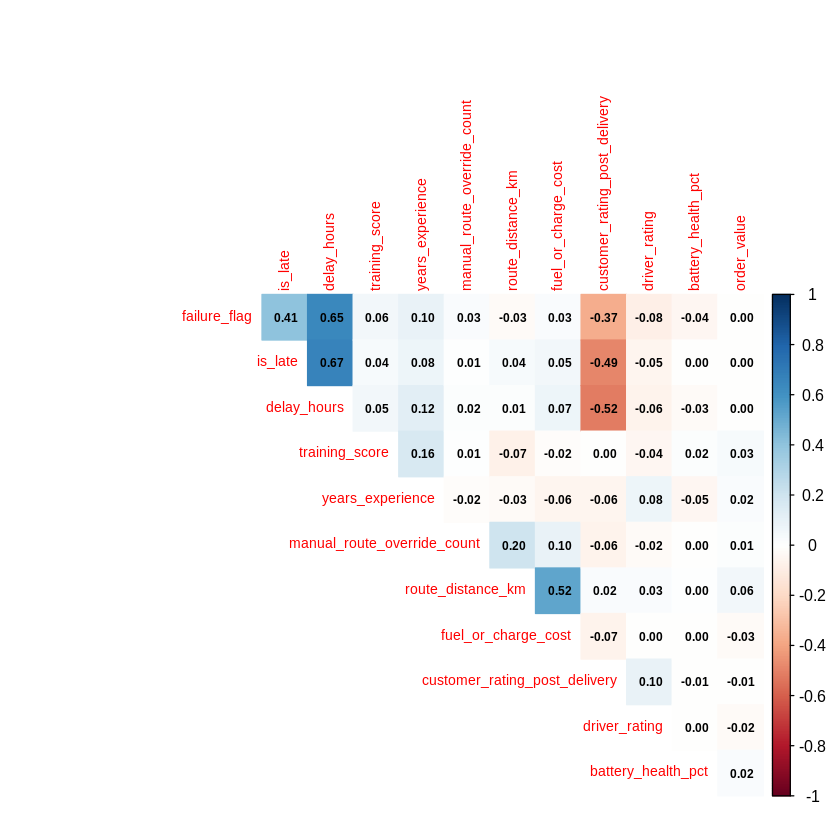

In [ ]:
# -----------------------------
# 13. Correlation analysis
# -----------------------------
correlation_data <- delivery_analysis %>%
  select(is_late, failure_flag, delay_hours, route_distance_km,
         manual_route_override_count, fuel_or_charge_cost,
         customer_rating_post_delivery, training_score, years_experience,
         driver_rating, battery_health_pct, order_value) %>%
  drop_na()

correlation_matrix <- cor(correlation_data)
print(round(correlation_matrix, 3))

corrplot(correlation_matrix, method = "color", type = "upper", order = "hclust",
         addCoef.col = "black", tl.cex = 0.7, number.cex = 0.6, diag = FALSE,
         col = COL2('RdBu', 200))

# -----------------------------
# 14. Normality Testing (Shapiro-Wilk)
# -----------------------------

We will perform Shapiro-Wilk tests on key numerical variables to check for normality. A p-value less than a chosen significance level (e.g., 0.05) indicates that the data is not normally distributed.

Note: The Shapiro-Wilk test is sensitive to large sample sizes, often rejecting normality even for small deviations.

In [ ]:
numerical_vars <- c("delay_hours", "route_distance_km", "fuel_or_charge_cost",
                      "customer_rating_post_delivery", "training_score",
                      "years_experience", "driver_rating", "battery_health_pct",
                      "order_value")

normality_results <- data.frame(
  variable = character(),
  W_statistic = numeric(),
  p_value = numeric(),
  stringsAsFactors = FALSE
)

for (var in numerical_vars) {
  # Remove NAs for the test
  data_for_test <- na.omit(delivery_analysis[[var]])

  # Shapiro-Wilk test (limited to 5000 samples for R's default implementation)
  if (length(data_for_test) > 3 & length(data_for_test) <= 5000) {
    shapiro_test_result <- shapiro.test(data_for_test)
    normality_results <- rbind(normality_results, data.frame(
      variable = var,
      W_statistic = shapiro_test_result$statistic,
      p_value = shapiro_test_result$p.value,
      stringsAsFactors = FALSE
    ))
  } else if (length(data_for_test) > 5000) {
    normality_results <- rbind(normality_results, data.frame(
      variable = var,
      W_statistic = NA,
      p_value = "Sample size > 5000 (Shapiro-Wilk limit)",
      stringsAsFactors = FALSE
    ))
  } else {
    normality_results <- rbind(normality_results, data.frame(
      variable = var,
      W_statistic = NA,
      p_value = "Sample size too small (<4)",
      stringsAsFactors = FALSE
    ))
  }
}

print(normality_results)

# Interpretation:
# If p-value < 0.05, reject the null hypothesis of normality.
# Many variables are likely non-normal, especially with larger datasets where the test is more sensitive.

                        variable W_statistic      p_value
W                    delay_hours   0.6747936 3.615503e-39
W1             route_distance_km   0.9326733 2.893866e-20
W2           fuel_or_charge_cost   0.9946325 1.877603e-03
W3 customer_rating_post_delivery   0.9304846 1.387972e-20
W4                training_score   0.9772994 5.180309e-11
W5              years_experience   0.9522333 5.204281e-17
W6                 driver_rating   0.9881429 5.970342e-07
W7            battery_health_pct   0.9845349 1.762505e-08
W8                   order_value   0.9044919 6.729676e-24


# -----------------------------
# 15. Welch t-tests
# -----------------------------

Welch's t-test is used to compare the means of two independent groups, without assuming equal variances. We'll examine if there's a significant difference in `delay_hours` and `customer_rating_post_delivery` based on `is_late` and `failure_flag`.

In [ ]:
# Test 1: delay_hours by is_late
t_test_delay_late <- t.test(delay_hours ~ is_late, data = delivery_analysis)
print("Welch t-test: Delay Hours by Is Late")
print(t_test_delay_late)

# Business Interpretation:
# If p < 0.05, there's a statistically significant difference in average delay hours between late and non-late deliveries.
# This is expected, as 'is_late' is often a direct consequence of 'delay_hours'.


# Test 2: customer_rating_post_delivery by failure_flag
t_test_rating_failure <- t.test(customer_rating_post_delivery ~ failure_flag, data = delivery_analysis)
print("\nWelch t-test: Customer Rating by Failure Flag")
print(t_test_rating_failure)

# Business Interpretation:
# If p < 0.05, there's a statistically significant difference in average customer ratings between failed and successful deliveries.
# We would expect failed deliveries to have significantly lower customer ratings, indicating a direct impact on customer satisfaction.

[1] "Welch t-test: Delay Hours by Is Late"

	Welch Two Sample t-test

data:  delay_hours by is_late
t = -25.371, df = 434, p-value < 2.2e-16
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -6.894987 -5.903495
sample estimates:
mean in group 0 mean in group 1 
       0.000000        6.399241 

[1] "\nWelch t-test: Customer Rating by Failure Flag"

	Welch Two Sample t-test

data:  customer_rating_post_delivery by failure_flag
t = 11.628, df = 170.28, p-value < 2.2e-16
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 0.7858504 1.1072099
sample estimates:
mean in group 0 mean in group 1 
       3.995697        3.049167 



# -----------------------------
# 16. Kruskal-Wallis Test
# -----------------------------

The Kruskal-Wallis test is a non-parametric alternative to one-way ANOVA, used to compare medians of three or more independent groups. It's suitable when the data does not meet the assumptions of normality or equal variances.

We will use it to assess if there are significant differences in `delay_hours` and `customer_rating_post_delivery` across different `service_type` and `hub_name` categories.